true label: 0 N_A
pred label: 0 N_A
crop path: D:\Hand_Gesture\data\dataset_v3_processed_detected\crops\four_367a6233-3e92-41fd-9ddf-a64312d8ac7d.jpg
landmark path: D:\Hand_Gesture\data\dataset_v3_processed_detected\landmarks\four_367a6233-3e92-41fd-9ddf-a64312d8ac7d.npy


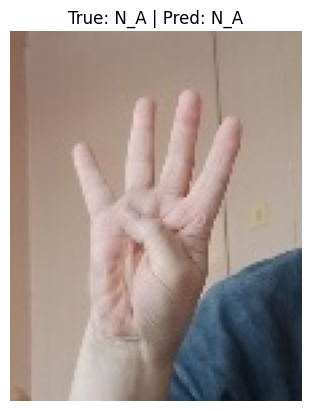

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from inference import predict

class_names = ["N_A", "fist", "like", "ok", "one", "palm"]

base_dir = Path("C:\NTHU_3rd2\IM\Final Project\Multimedia-HandGesture_project\processed_hagrid_small")
crop_dir = base_dir / "crops"
landmark_dir = base_dir / "landmarks"

df = pd.read_csv(base_dir / "labels.csv")

row = df.sample(1, random_state=0).iloc[0]

# 從舊路徑只取檔名
crop_name = Path(row["crop_path"]).name
landmark_name = Path(row["landmark_path"]).name

# 接到你自己的資料夾
crop_path = crop_dir / crop_name
landmark_path = landmark_dir / landmark_name

crop_img = np.array(Image.open(crop_path).convert("RGB"))
landmarks = np.load(landmark_path)

pred = predict(crop_img, landmarks)

print("true label:", row["label"], row["label_name"])
print("pred label:", pred, class_names[pred])
print("crop path:", crop_path)
print("landmark path:", landmark_path)

plt.imshow(crop_img)
plt.title(f"True: {row['label_name']} | Pred: {class_names[pred]}")
plt.axis("off")
plt.show()

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image

from inference import predict

class_names = ["N_A", "fist", "like", "ok", "one", "palm"]

base_dir = Path("D:/Hand_Gesture/data/dataset_v3_processed_detected")
crop_dir = base_dir / "crops"
landmark_dir = base_dir / "landmarks"

df = pd.read_csv(base_dir / "labels.csv")

correct = 0
total = 0
results = []

sample_df = df.sample(min(2000, len(df)), random_state=1)

for row in sample_df.itertuples():
    # 只取舊路徑的檔名
    crop_name = Path(row.crop_path).name
    landmark_name = Path(row.landmark_path).name

    # 接到你自己的資料夾
    crop_path = crop_dir / crop_name
    landmark_path = landmark_dir / landmark_name

    crop_img = np.array(Image.open(crop_path).convert("RGB"))
    landmarks = np.load(landmark_path)


    pred = predict(crop_img, landmarks)
    true = int(row.label)

    correct += int(pred == true)
    total += 1

    results.append({
        "true": true,
        "true_name": row.label_name,
        "pred": pred,
        "pred_name": class_names[pred],
        "crop_path": str(crop_path),
        "landmark_path": str(landmark_path),
    })

result_df = pd.DataFrame(results)

print("accuracy:", correct / total)
print(result_df.head())

accuracy: 0.9715
   true true_name  pred pred_name  \
0     0       N_A     0       N_A   
1     4       one     4       one   
2     5      palm     5      palm   
3     0       N_A     0       N_A   
4     1      fist     1      fist   

                                           crop_path  \
0  D:\Hand_Gesture\data\dataset_v3_processed_dete...   
1  D:\Hand_Gesture\data\dataset_v3_processed_dete...   
2  D:\Hand_Gesture\data\dataset_v3_processed_dete...   
3  D:\Hand_Gesture\data\dataset_v3_processed_dete...   
4  D:\Hand_Gesture\data\dataset_v3_processed_dete...   

                                       landmark_path  
0  D:\Hand_Gesture\data\dataset_v3_processed_dete...  
1  D:\Hand_Gesture\data\dataset_v3_processed_dete...  
2  D:\Hand_Gesture\data\dataset_v3_processed_dete...  
3  D:\Hand_Gesture\data\dataset_v3_processed_dete...  
4  D:\Hand_Gesture\data\dataset_v3_processed_dete...  


In [6]:
cm = pd.crosstab(
    result_df["true_name"],
    result_df["pred_name"],
    rownames=["True"],
    colnames=["Pred"],
    dropna=False
)

cm = cm.reindex(index=class_names, columns=class_names, fill_value=0)

display(cm)

Pred,N_A,fist,like,ok,one,palm
True,,,,,,
N_A,1042,2,2,0,0,2
fist,8,187,0,0,0,0
like,4,0,165,0,0,0
ok,9,0,0,179,0,0
one,18,0,0,0,182,0
palm,12,0,0,0,0,188


wrong count: 57


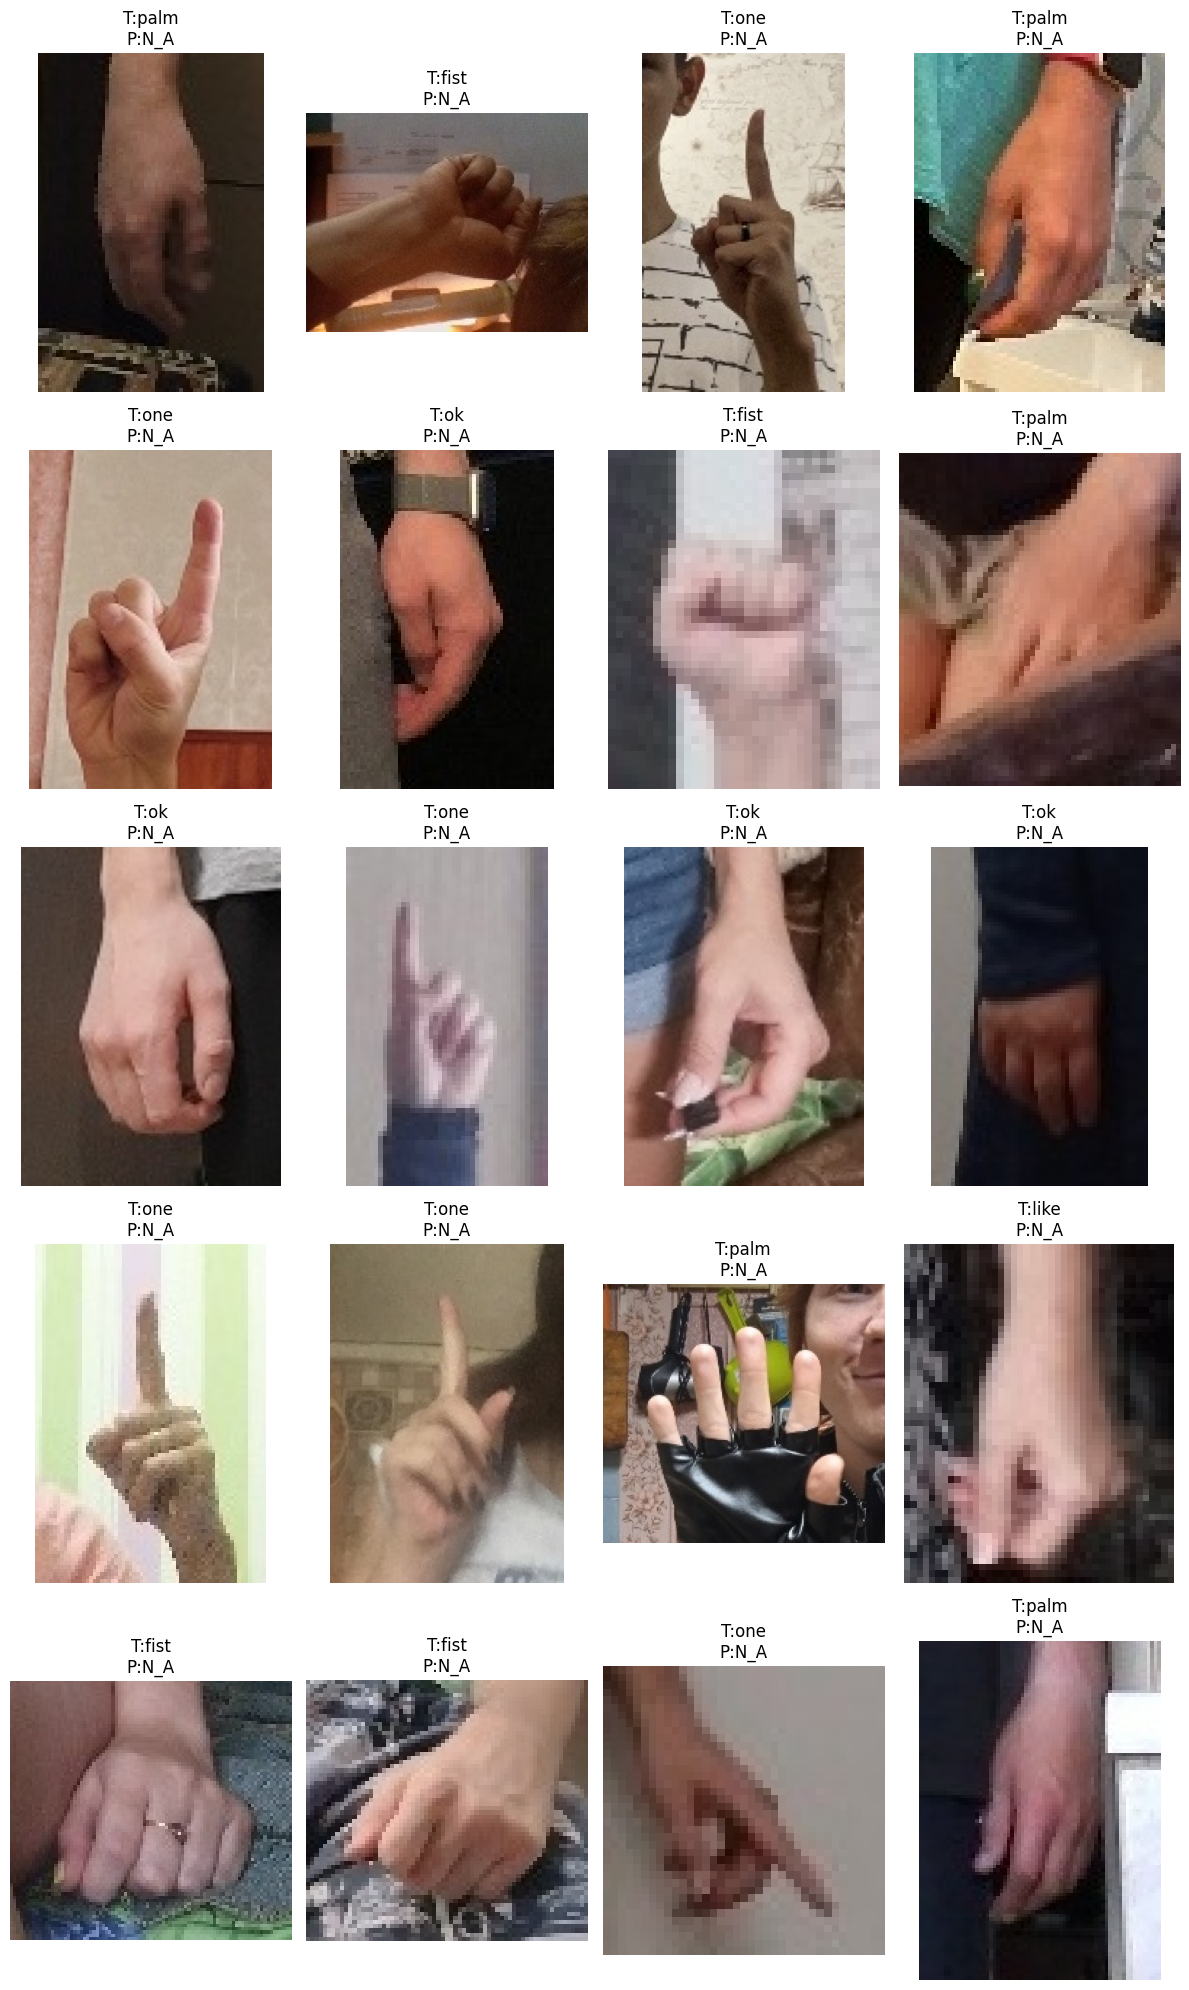

In [7]:
wrong_df = result_df[result_df["true"] != result_df["pred"]]

print("wrong count:", len(wrong_df))

show_df = wrong_df.head(20)

plt.figure(figsize=(12, 20))

for i, row in enumerate(show_df.itertuples()):
    img = Image.open(row.crop_path).convert("RGB")

    plt.subplot(5, 4, i + 1)
    plt.imshow(img)
    plt.title(f"T:{row.true_name}\nP:{row.pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()